# Chapter 4. 카운트 기반의 문서표현



## 4.2 BOW 기반의 카운트 벡터 생성

In [ ]:
import nltk
nltk.download('movie_reviews')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('webtext')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('tagsets_json')

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package webtext to /root/nltk_data...
[nltk_data]   Package webtext is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-

True

- 데이터 확인

In [ ]:
from nltk.corpus import movie_reviews

print('#review count:', len(movie_reviews.fileids()))
print('#samples of file ids:', movie_reviews.fileids()[:10])

#review count: 2000
#samples of file ids: ['neg/cv000_29416.txt', 'neg/cv001_19502.txt', 'neg/cv002_17424.txt', 'neg/cv003_12683.txt', 'neg/cv004_12641.txt', 'neg/cv005_29357.txt', 'neg/cv006_17022.txt', 'neg/cv007_4992.txt', 'neg/cv008_29326.txt', 'neg/cv009_29417.txt']


In [ ]:
print('#categories of reviews:', movie_reviews.categories()) # label, 즉 긍정인지 부정인지에 대한 분류
print('#num of "neg" reviews:', len(movie_reviews.fileids(categories='neg'))) #label이 부정인 문서들의 id를 반환
print('#num of "pos" reviews:', len(movie_reviews.fileids(categories='pos'))) #label이 긍정인 문서들의 id를 반환

#categories of reviews: ['neg', 'pos']
#num of "neg" reviews: 1000
#num of "pos" reviews: 1000


In [ ]:
fileid = movie_reviews.fileids()[0]
print('#id of the first review:', fileid)
category = movie_reviews.categories(fileid)
print('Review category:', category)
print('#first review content:\n', movie_reviews.raw(fileid)[:200]) #첫번째 문서의 내용을 200자까지만 출력

#id of the first review: neg/cv000_29416.txt
Review category: ['neg']
#first review content:
 plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
w


In [ ]:
print('#sentence tokenization result:', movie_reviews.sents(fileid)[:2])
print('#word tokenization result:', movie_reviews.words(fileid)[:20])

#sentence tokenization result: [['plot', ':', 'two', 'teen', 'couples', 'go', 'to', 'a', 'church', 'party', ',', 'drink', 'and', 'then', 'drive', '.'], ['they', 'get', 'into', 'an', 'accident', '.']]
#word tokenization result: ['plot', ':', 'two', 'teen', 'couples', 'go', 'to', 'a', 'church', 'party', ',', 'drink', 'and', 'then', 'drive', '.', 'they', 'get', 'into', 'an']


In [ ]:

documents = [list(movie_reviews.words(fileid)) for fileid in movie_reviews.fileids()]
print(documents[0][:50])

['plot', ':', 'two', 'teen', 'couples', 'go', 'to', 'a', 'church', 'party', ',', 'drink', 'and', 'then', 'drive', '.', 'they', 'get', 'into', 'an', 'accident', '.', 'one', 'of', 'the', 'guys', 'dies', ',', 'but', 'his', 'girlfriend', 'continues', 'to', 'see', 'him', 'in', 'her', 'life', ',', 'and', 'has', 'nightmares', '.', 'what', "'", 's', 'the', 'deal', '?', 'watch']


In [ ]:
word_count = {}
for text in documents:
    for word in text:
        word_count[word] = word_count.get(word, 0) + 1

sorted_features = sorted(word_count, key=word_count.get, reverse=True)
print(len(sorted_features))
for word in sorted_features[:10]:
    print(f"count of '{word}': {word_count[word]}", end=', ')

39768
count of ',': 77717, count of 'the': 76529, count of '.': 65876, count of 'a': 38106, count of 'and': 35576, count of 'of': 34123, count of 'to': 31937, count of ''': 30585, count of 'is': 25195, count of 'in': 21822, 

- 텍스트 전처리

In [ ]:
documents = [movie_reviews.raw(fileid) for fileid in movie_reviews.fileids()]
print(len(documents))  # 문서 수 출력 (예: 2000)
print(documents[0][:200])

2000
plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
w


In [ ]:
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords

tokenizer = RegexpTokenizer(r"[\w']{3,}")
english_stops = set(stopwords.words('english'))

tokens = [[token for token in tokenizer.tokenize(doc) if token not in english_stops] for doc in documents]
print(len(tokens[0]))

323


In [ ]:
word_count = {}
for text in tokens:
    for word in text:
        word_count[word] = word_count.get(word, 0) + 1

sorted_features = sorted(word_count, key=word_count.get, reverse=True)

print('num of features:', len(sorted_features))
for word in sorted_features[:10]:
    print(f"count of '{word}': {word_count[word]}", end=', ')

num of features: 43011
count of 'film': 8935, count of 'one': 5791, count of 'movie': 5538, count of 'like': 3690, count of 'even': 2564, count of 'time': 2409, count of 'good': 2407, count of 'story': 2136, count of 'would': 2084, count of 'much': 2049, 

In [ ]:
word_features = sorted_features[:1000]

In [ ]:
def document_features(document, word_features):
    word_count = {}
    for word in document:
        word_count[word] = word_count.get(word, 0) + 1

    features = []
    for word in word_features:
        features.append(word_count.get(word, 0))
    return features

word_features_ex = ['one', 'two', 'teen', 'couples', 'solo']
doc_ex = ['two', 'two', 'couples']
print(document_features(doc_ex, word_features_ex))

[0, 2, 0, 1, 0]


In [ ]:
#문서-단어 행렬(Document-Term Matrix, DTM)
feature_sets = [document_features(d, word_features) for d in tokens]

for i in range(20):
    print(f'({word_features[i]}, {feature_sets[0][i]})', end=', ')

(film, 5), (one, 3), (movie, 6), (like, 3), (even, 3), (time, 0), (good, 2), (story, 0), (would, 1), (much, 0), (also, 1), (get, 3), (character, 1), (two, 2), (well, 1), (first, 0), (characters, 1), (see, 2), (way, 3), (make, 5), 

In [ ]:
print(feature_sets[0][-20:])

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## 4.3 사이킷런을 이용한 카운트 벡터 생성

### CountVectorizer

http://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction  

In [ ]:
reviews = [movie_reviews.raw(fileid) for fileid in movie_reviews.fileids()]

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

#cv = CountVectorizer()
#cv = CountVectorizer(max_features=1000)

cv = CountVectorizer(vocabulary=word_features)

print(cv)

CountVectorizer(vocabulary=['film', 'one', 'movie', 'like', 'even', 'time',
                            'good', 'story', 'would', 'much', 'also', 'get',
                            'character', 'two', 'well', 'first', 'characters',
                            'see', 'way', 'make', 'life', 'really', 'films',
                            'plot', 'little', 'people', 'could', 'bad', 'scene',
                            'never', ...])


In [ ]:
reviews_cv = cv.fit_transform(reviews)
print(cv.get_feature_names_out()[:20])
print(word_features[:20])

['film' 'one' 'movie' 'like' 'even' 'time' 'good' 'story' 'would' 'much'
 'also' 'get' 'character' 'two' 'well' 'first' 'characters' 'see' 'way'
 'make']
['film', 'one', 'movie', 'like', 'even', 'time', 'good', 'story', 'would', 'much', 'also', 'get', 'character', 'two', 'well', 'first', 'characters', 'see', 'way', 'make']


In [ ]:
print('#type of count vectors:', type(reviews_cv))
print('#shape of count vectors:', reviews_cv.shape)
print('#sample of count vector:')
print(reviews_cv[0, :10])

#type of count vectors: <class 'scipy.sparse._csr.csr_matrix'>
#shape of count vectors: (2000, 1000)
#sample of count vector:
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 7 stored elements and shape (1, 10)>
  Coords	Values
  (0, 0)	6
  (0, 1)	3
  (0, 2)	6
  (0, 3)	3
  (0, 4)	3
  (0, 6)	2
  (0, 8)	1


In [ ]:
reviews_cv

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 253647 stored elements and shape (2000, 1000)>

In [ ]:
print(feature_sets[0][:20])
print(', '.join(map(str, reviews_cv.toarray()[0, :20])))

[5, 3, 6, 3, 3, 0, 2, 0, 1, 0, 1, 3, 1, 2, 1, 0, 1, 2, 3, 5]
6, 3, 6, 3, 3, 0, 2, 0, 1, 0, 1, 3, 2, 2, 1, 0, 1, 2, 3, 5


In [ ]:
for word, count in zip(cv.get_feature_names_out()[:20], reviews_cv[0].toarray()[0, :20]):
    print(f'{word}:{count}', end=', ')

film:6, one:3, movie:6, like:3, even:3, time:0, good:2, story:0, would:1, much:0, also:1, get:3, character:2, two:2, well:1, first:0, characters:1, see:2, way:3, make:5, 

## 4.4 한국어 텍스트의 카운트 벡터 변환
- 네이버 영화 리뷰 데이터

In [ ]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import urllib.request

In [ ]:
urllib.request.urlretrieve("https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt", filename="ratings_train.txt")
#urllib.request.urlretrieve("https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt", filename="ratings_test.txt")


('ratings_train.txt', <http.client.HTTPMessage at 0x7ca727135280>)

In [ ]:
df = pd.read_table('ratings_train.txt')
df.head(10)

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1
5,5403919,막 걸음마 뗀 3세부터 초등학교 1학년생인 8살용영화.ㅋㅋㅋ...별반개도 아까움.,0
6,7797314,원작의 긴장감을 제대로 살려내지못했다.,0
7,9443947,별 반개도 아깝다 욕나온다 이응경 길용우 연기생활이몇년인지..정말 발로해도 그것보단...,0
8,7156791,액션이 없는데도 재미 있는 몇안되는 영화,1
9,5912145,왜케 평점이 낮은건데? 꽤 볼만한데.. 헐리우드식 화려함에만 너무 길들여져 있나?,1


In [ ]:
# df 전처리
print(df.columns)

print(df['document'].isnull().sum())
df = df.dropna(subset=['document'])  # 결측값 있는 행 삭제 또는 아래와 같이 대체 가능

df['document'] = df['document'].astype(str)

Index(['id', 'document', 'label'], dtype='object')
5


- 카운트벡터 만들기

In [ ]:
# 단어집합: 상위 1000개 기준
from sklearn.feature_extraction.text import CountVectorizer
naver_cv = CountVectorizer(max_features=1000)

naver_DTM = naver_cv.fit_transform(df.document)
print(naver_cv.get_feature_names_out()[:100])

['0점' '0점은' '10' '10점' '1점' '1점도' '2점' '3류' '3점' '4점' '80년대' '90년대' '9점'
 'b급' 'good' 'oo' 'ooo' 'ooo기' 'ost' 'the' 'tv' 'ㄷㄷ' 'ㅅㅂ' 'ㅇㅇ' 'ㅉㅉ' 'ㅋㅋ'
 'ㅋㅋㅋ' 'ㅋㅋㅋㅋ' 'ㅋㅋㅋㅋㅋ' 'ㅎㅎ' 'ㅎㅎㅎ' 'ㅜㅜ' 'ㅠㅠ' 'ㅠㅠㅠ' 'ㅡㅡ' '가끔' '가는' '가볍게' '가서'
 '가슴' '가슴이' '가장' '가족' '가지고' '가진' '각본' '간만에' '갈수록' '감독' '감독님' '감독은' '감독의'
 '감독이' '감동' '감동과' '감동도' '감동을' '감동이' '감동적이고' '감동적인' '감사합니다' '감정을' '갑자기'
 '강추' '같네요' '같다' '같습니다' '같아' '같아서' '같아요' '같은' '같은데' '같음' '같이' '개연성'
 '개인적으로' '거의' '건지' '걸작' '겁나' '것도' '것은' '것을' '것이' '것이다' '게다가' '결국' '결말'
 '결말도' '결말은' '결말이' '계속' '공감' '공감이' '공포' '공포영화' '과연' '괜찮은' '괜히' '굉장히']


- 유의미한 단어집합으로 카운트벡터 만들기

In [ ]:
!pip install konlpy

In [ ]:
from konlpy.tag import Okt
twitter_tag = Okt()

print('#전체 형태소 결과:', twitter_tag.morphs(df.document[1]))
print('#명사만 추출:', twitter_tag.nouns(df.document[1]))
print('#품사 태깅 결과', twitter_tag.pos(df.document[1]))

#전체 형태소 결과: ['흠', '...', '포스터', '보고', '초딩', '영화', '줄', '....', '오버', '연기', '조차', '가볍지', '않구나']
#명사만 추출: ['흠', '포스터', '보고', '초딩', '영화', '줄', '오버', '연기']
#품사 태깅 결과 [('흠', 'Noun'), ('...', 'Punctuation'), ('포스터', 'Noun'), ('보고', 'Noun'), ('초딩', 'Noun'), ('영화', 'Noun'), ('줄', 'Noun'), ('....', 'Punctuation'), ('오버', 'Noun'), ('연기', 'Noun'), ('조차', 'Josa'), ('가볍지', 'Adjective'), ('않구나', 'Verb')]


In [ ]:
def my_tokenizer(doc):
    return [token for token, pos in twitter_tag.pos(doc) if pos in ['Noun', 'Verb', 'Adjective']]

print(df.document[1])
print("나만의 토크나이저 결과:", my_tokenizer(df.document[1]))

흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나
나만의 토크나이저 결과: ['흠', '포스터', '보고', '초딩', '영화', '줄', '오버', '연기', '가볍지', '않구나']


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer


naver_cv2 = CountVectorizer(max_features=1000, tokenizer=my_tokenizer)

# naver_DTM2 = naver_cv2.fit_transform(df['document'])
naver_DTM2 = naver_cv2.fit_transform( df['document'][:1000])


print(naver_cv2.get_feature_names_out()[:100]) # count vector에 사용된 feature 이름을 반환

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


['가' '가서' '가슴' '가슴속' '가안' '가요' '가장' '가족' '간다' '간만' '갈등' '갈수록' '감' '감독'
 '감동' '감사합니다' '감성' '감정' '같다' '같아요' '같은' '같은데' '같음' '개' '개봉' '개연' '개인' '거'
 '거기' '건' '건가' '건지' '걸' '검술' '겁나' '겁니다' '것' '게' '결말' '계속' '고추' '공감' '공부'
 '공포' '공포영화' '관객' '괜찮은' '구' '구성' '구역' '국민' '국산' '군더더기' '굳' '굿' '굿바이'
 '궁금하다' '귀신' '귀여운' '귀엽다' '그' '그것' '그게' '그냥' '그녀' '그대로' '그때' '그래픽' '그런'
 '그런지' '그럴' '그렇고' '그릇' '그리' '그립다' '극' '극장' '극장판' '극적' '극치' '근래' '급' '기'
 '기대' '기도' '기분' '기술' '기억' '기적' '기존' '기키' '긴장감' '길' '깊은' '깊이' '까' '까야' '깨알'
 '꼬마' '꼭']


In [ ]:
print(repr(naver_DTM2))
# print(110800/(14725*1000))
print(5408 /(1000 * 1000))

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 5408 stored elements and shape (1000, 1000)>
0.005408


In [ ]:
for word, count in zip(naver_cv2.get_feature_names_out(), naver_DTM2[1].toarray()[0]):
    if count > 0:
        print(word, ':', count, end=', ')

보고 : 1, 연기 : 1, 영화 : 1, 오버 : 1, 줄 : 1, 초딩 : 1, 포스터 : 1, 

## 4.5 카운트 벡터의 활용

### 코사인 유사도(Cosine similarity)

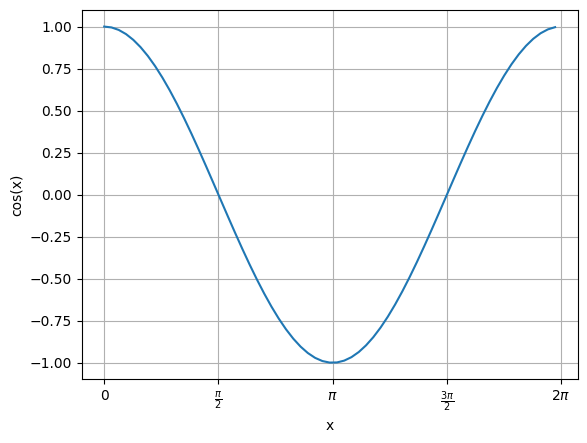

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(0, 2 * np.pi, 0.1)
y = np.cos(x)

plt.plot(x, y)

pi_ticks = np.pi * np.array([0, 0.5, 1, 1.5, 2])
pi_labels = ['0', r'$\frac{\pi}{2}$', r'$\pi$', r'$\frac{3\pi}{2}$', r'$2\pi$']
plt.xticks(pi_ticks, pi_labels)

plt.xlabel('x')
plt.ylabel('cos(x)')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

start = len(reviews[0])
source = reviews[0][-start:]

source_cv = cv.transform([source])

print("#대상 특성 행렬의 크기:", source_cv.shape)

#대상 특성 행렬의 크기: (1, 1000)


In [ ]:
sim_result = cosine_similarity(source_cv, reviews_cv) #변환된 count vector와 기존 값들과의 similarity 계산

print("#유사도 계산 행렬의 크기:", sim_result.shape)
print("#유사도 계산결과를 역순으로 정렬:", sorted(sim_result[0], reverse=True)[:10])

#유사도 계산 행렬의 크기: (1, 2000)
#유사도 계산결과를 역순으로 정렬: [np.float64(1.0000000000000018), np.float64(0.5156085525826023), np.float64(0.5037806366451232), np.float64(0.5020139986107867), np.float64(0.501228003296025), np.float64(0.5006544852712335), np.float64(0.49907773307516046), np.float64(0.49661393707531765), np.float64(0.49298361778895117), np.float64(0.4929200786026572)]


In [ ]:
import numpy as np

most_similar_index = np.argmax(sim_result[0])
print('#가장 유사한 리뷰의 인덱스:', most_similar_index)

file_id = movie_reviews.fileids()[most_similar_index]
label = movie_reviews.categories(file_id)
print(f"파일 ID: {file_id}")
print(f"해당 리뷰의 라벨: {label[0]}")  # 문자열로 출력 ('pos' 또는 'neg')

#가장 유사한 리뷰의 인덱스: 0
파일 ID: neg/cv000_29416.txt
해당 리뷰의 라벨: neg


In [ ]:
top_10_indices = np.argsort(sim_result[0])[::-1][:10]
print('#가장 유사한 리뷰부터 정렬한 인덱스:', top_10_indices)

for idx in top_10_indices:
    file_id = movie_reviews.fileids()[idx]
    label = movie_reviews.categories(file_id)[0]
    print(f"리뷰 인덱스: {idx}, 파일 ID: {file_id}, 라벨: {label}")

#가장 유사한 리뷰부터 정렬한 인덱스: [   0 1110 1518 1570  623  323  647  485  428  687]
리뷰 인덱스: 0, 파일 ID: neg/cv000_29416.txt, 라벨: neg
리뷰 인덱스: 1110, 파일 ID: pos/cv110_27788.txt, 라벨: pos
리뷰 인덱스: 1518, 파일 ID: pos/cv518_13331.txt, 라벨: pos
리뷰 인덱스: 1570, 파일 ID: pos/cv570_29082.txt, 라벨: pos
리뷰 인덱스: 623, 파일 ID: neg/cv623_16988.txt, 라벨: neg
리뷰 인덱스: 323, 파일 ID: neg/cv323_29633.txt, 라벨: neg
리뷰 인덱스: 647, 파일 ID: neg/cv647_15275.txt, 라벨: neg
리뷰 인덱스: 485, 파일 ID: neg/cv485_26879.txt, 라벨: neg
리뷰 인덱스: 428, 파일 ID: neg/cv428_12202.txt, 라벨: neg
리뷰 인덱스: 687, 파일 ID: neg/cv687_22207.txt, 라벨: neg


## 4.6 TF-IDF로 성능을 높여보자

In [ ]:
from sklearn.feature_extraction.text import TfidfTransformer

#reviews_cv
transformer = TfidfTransformer()
reviews_tfidf = transformer.fit_transform(reviews_cv)
print('#shape of tfidf matrix:', reviews_tfidf.shape) #TF-IDF 행렬의 모양과 카운트 행렬의 모양이 일치하는 것을 확인

print('#20 count score of the first review:', reviews_cv[0].toarray()[0][:20])
print('#20 tfidf score of the first review:', reviews_tfidf[0].toarray()[0][:20])

#shape of tfidf matrix: (2000, 1000)
#20 count score of the first review: [6 3 6 3 3 0 2 0 1 0 1 3 2 2 1 0 1 2 3 5]
#20 tfidf score of the first review: [0.13556199 0.06700076 0.14998642 0.0772298  0.08608998 0.
 0.0609124  0.         0.03126552 0.         0.03242315 0.09567082
 0.06575035 0.06518293 0.03225625 0.         0.0345017  0.06863314
 0.10042383 0.16727495]


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tf = TfidfVectorizer(vocabulary=word_features)
reviews_tf = tf.fit_transform(reviews)
print('#20 tfidf score of the first review:', reviews_tf[0].toarray()[0][:20])


#20 tfidf score of the first review: [0.13556199 0.06700076 0.14998642 0.0772298  0.08608998 0.
 0.0609124  0.         0.03126552 0.         0.03242315 0.09567082
 0.06575035 0.06518293 0.03225625 0.         0.0345017  0.06863314
 0.10042383 0.16727495]


In [ ]:
source_tf = tf.transform([source])
sim_result_tf = cosine_similarity(source_tf, reviews_tf)

print('#가장 유사한 리뷰의 인덱스:', np.argmax(sim_result_tf[0]))

#가장 유사한 리뷰의 인덱스: 0


In [ ]:
print('#카운트 벡터에 대해 가장 유사한 리뷰부터 정렬한 인덱스:', (-sim_result[0]).argsort()[:10])
print('#TF-IDF 벡터에 대해 가장 유사한 리뷰부터 정렬한 인덱스:', (-sim_result_tf[0]).argsort()[:10])

#카운트 벡터에 대해 가장 유사한 리뷰부터 정렬한 인덱스: [   0 1110 1518 1570  623  323  647  485  428  687]
#TF-IDF 벡터에 대해 가장 유사한 리뷰부터 정렬한 인덱스: [   0  428  323 1110  645  647 1668 1570  511  488]


In [ ]:
top_10_indices = np.argsort(sim_result_tf[0])[::-1][:10]
print("상위 10개 유사 리뷰의 인덱스:", top_10_indices)
for idx in top_10_indices:
    file_id = movie_reviews.fileids()[idx]
    label = movie_reviews.categories(file_id)[0]

    print(f"리뷰 인덱스: {idx}, 파일 ID: {file_id}, 라벨: {label}")

상위 10개 유사 리뷰의 인덱스: [   0  428  323 1110  645  647 1668 1570  511  488]
리뷰 인덱스: 0, 파일 ID: neg/cv000_29416.txt, 라벨: neg
리뷰 인덱스: 428, 파일 ID: neg/cv428_12202.txt, 라벨: neg
리뷰 인덱스: 323, 파일 ID: neg/cv323_29633.txt, 라벨: neg
리뷰 인덱스: 1110, 파일 ID: pos/cv110_27788.txt, 라벨: pos
리뷰 인덱스: 645, 파일 ID: neg/cv645_17078.txt, 라벨: neg
리뷰 인덱스: 647, 파일 ID: neg/cv647_15275.txt, 라벨: neg
리뷰 인덱스: 1668, 파일 ID: pos/cv668_17604.txt, 라벨: pos
리뷰 인덱스: 1570, 파일 ID: pos/cv570_29082.txt, 라벨: pos
리뷰 인덱스: 511, 파일 ID: neg/cv511_10360.txt, 라벨: neg
리뷰 인덱스: 488, 파일 ID: neg/cv488_21453.txt, 라벨: neg
